# Normal toy example using SBI

In [ ]:
import torch
import numpy as np
from torch.distributions import Uniform
from sbi.inference import NPE_C, simulate_for_sbi
from sbi.utils.user_input_checks import (
    check_sbi_inputs,
    process_prior,
    process_simulator,
)
from sbi.utils.user_input_checks import MultipleIndependent
from scipy.stats import norm, uniform
from sbi.analysis import plot_summary
import matplotlib.pyplot as plt
import seaborn as sns


torch_device = "cpu"
torch.set_default_device(torch_device)

c:\Users\u2008181\likelihood-free\sbi_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
WARNING (pytensor.configdefaults): g++ not available, if using conda: `conda install gxx`
WARNING (pytensor.configdefaults): g++ not detected!  PyTensor will be unable to compile C-implementations and will default to Python. Performance may be severely degraded. To remove this warning, set PyTensor flags cxx to an empty string.


## Model 1

**Prior:**
-  $\mu \sim \text{Uniform}[0, 10]$
-  $\sigma \sim \text{Uniform}[1, 10]$

**Simulator:**
-  $x \sim N(\mu, \sigma^2)$

In [2]:
theta = np.full((100, 2), np.nan)
theta[:, 0] = np.random.uniform(0, 10, size=100)
theta[:, 1] = np.random.uniform(1, 10, size=100)
mu_y = np.full(100, np.nan)
sigma_y = np.full(100, np.nan)

for i in range(100):
    # mu_y[i] = np.random.normal(loc=2*theta[i, 0]+3*theta[i, 0]**2, scale=3)
    mu_y[i] = np.random.normal(loc=theta[i, 0], scale=3)
    # sigma_y[i] = np.random.normal(loc=2*5+theta[i, 1]*5**2, scale=theta[i, 1])
    sigma_y[i] = np.random.normal(loc=5, scale=theta[i, 1])

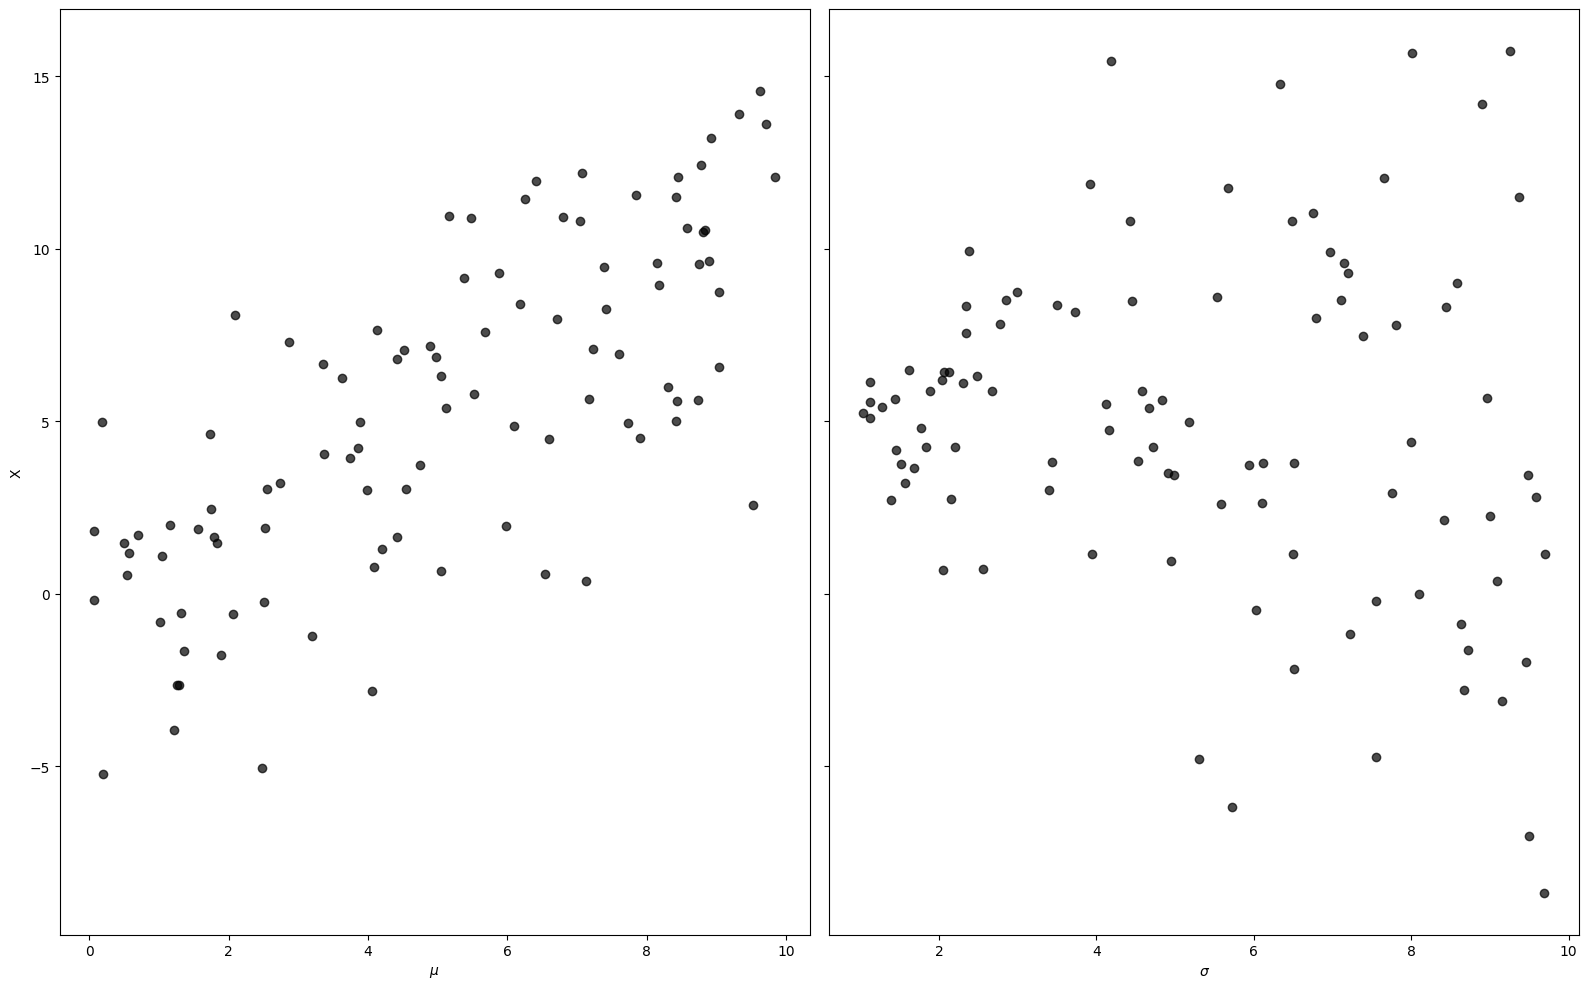

In [3]:
fig, axs = plt.subplots(1, 2, figsize=(16, 10), sharey='row')

axs[0].scatter(theta[:, 0], mu_y, marker='o', color='black', alpha=0.7)
axs[1].scatter(theta[:, 1], sigma_y, marker='o', color='black', alpha=0.7)

axs[0].set_xlabel(r'$\mu$')
axs[1].set_xlabel(r'$\sigma$')

axs[0].set_ylabel('X')

plt.tight_layout()
plt.show()

In [4]:
prior_mu = Uniform(low=torch.tensor([0.0]), high=torch.tensor([10.0]))
prior_sigma = Uniform(low=torch.tensor([1.0]), high=torch.tensor([10.0]))

prior_torch = MultipleIndependent(
    dists=[prior_mu, prior_sigma],
    validate_args=False,
    device=torch_device
)

In [5]:
def simulator_1(theta):
    x = torch.randn(1, device=torch_device) * theta[1] + theta[0]
    out_torch = torch.tensor([x, theta[1]], device=torch_device)
    return out_torch

## NPE-C

In [6]:
simulation_budget = 10000
num_posterior_samples=1000
seed = 1

In [7]:
simulator = simulator_1

prior, num_parameters, prior_returns_numpy = process_prior(prior_torch)
simulator = process_simulator(simulator, prior, prior_returns_numpy)
check_sbi_inputs(simulator, prior)

learning_rate = 0.0005  # default value

torch.manual_seed(seed)
np.random.seed(seed)

theta, x = simulate_for_sbi(
    simulator=simulator, proposal=prior, num_simulations=simulation_budget
)

100%|██████████| 10000/10000 [00:00<00:00, 16519.24it/s]


In [8]:
def run_npe(theta, x, seed=1, num_epochs=500):
    torch.manual_seed(seed)
    np.random.seed(seed)
    learning_rate = 0.0005  # default value

    inference = NPE_C(density_estimator="nsf", device=torch_device)

    density_estimator = inference.append_simulations(theta, x).train(
        max_num_epochs=num_epochs, 
        learning_rate=learning_rate,
        stop_after_epochs=20
    )

    fig, axes = plot_summary(
        inference, 
        tags=["training_loss", "validation_loss"], 
        figsize=(8, 4)
    )
    plt.title("Training and Validation Loss")
    plt.show()

    return inference.build_posterior(density_estimator)

**Simulator 1**

sigma inside the parameter space.

 Training neural network. Epochs trained: 150

For an interactive, detailed view of the summary, launch tensorboard  with 'tensorboard --logdir=c:\Users\u2008181\likelihood-free\python\normal_toy\sbi-logs\NPE_C\2026-06-01T14_56_56.668349' from a terminal on your machine, visit http://127.0.0.1:6006 afterwards. Requires port forwarding if tensorboard runs on a remote machine, as e.g. https://stackoverflow.com/a/42445070/7770835 explains.

Valid tags are: ['best_validation_loss', 'epoch_durations_sec', 'epochs_trained', 'training_loss', 'validation_loss'].


 Neural network successfully converged after 151 epochs.

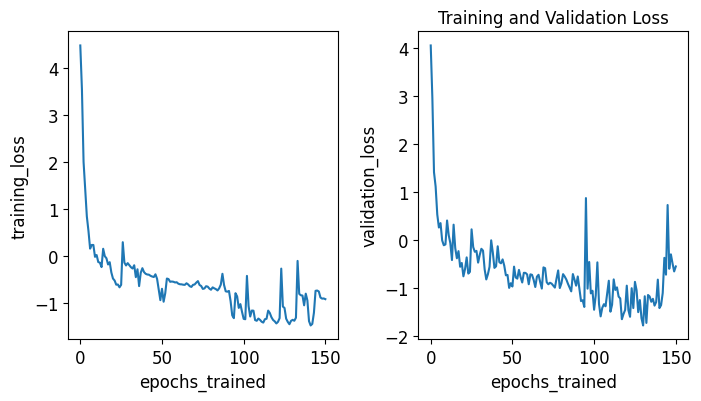

In [9]:
posterior_1 = run_npe(theta, x)

**Simulator 2**

sigma outside the parameter space

In [10]:
theta2 = theta[:, 0:1]
theta2

tensor([[0.2569],
        [0.6235],
        [2.2045],
        ...,
        [9.0977],
        [8.0192],
        [1.6477]])

 Training neural network. Epochs trained: 77

For an interactive, detailed view of the summary, launch tensorboard  with 'tensorboard --logdir=c:\Users\u2008181\likelihood-free\python\normal_toy\sbi-logs\NPE_C\2026-06-01T15_06_50.025850' from a terminal on your machine, visit http://127.0.0.1:6006 afterwards. Requires port forwarding if tensorboard runs on a remote machine, as e.g. https://stackoverflow.com/a/42445070/7770835 explains.

Valid tags are: ['best_validation_loss', 'epoch_durations_sec', 'epochs_trained', 'training_loss', 'validation_loss'].


 Neural network successfully converged after 78 epochs.

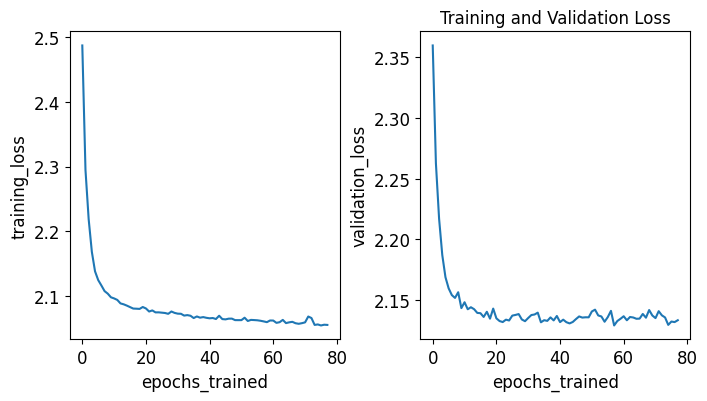

In [11]:
posterior_2 = run_npe(theta2, x)

If the true values are:
-  $\mu = 6.0$,
-  $\sigma = 4.5$.

The observed summary statistics are shown below as

In [12]:
torch.manual_seed(1)
np.random.seed(1)
true_theta = torch.tensor([6.0, 4.5], device=torch_device)
x_o = simulator_1(true_theta)
true_theta, x_o

(tensor([6.0000, 4.5000]), tensor([8.9761, 4.5000]))

Plug in observed data to get the posterior.

In [16]:
theta_trained1 = posterior_1.sample((num_posterior_samples,), x=x_o)
theta_trained1_numpy = theta_trained1.cpu().numpy()

theta_trained2 = posterior_2.sample((num_posterior_samples,), x=x_o)
theta_trained2_numpy = theta_trained2.cpu().numpy()

100%|██████████| 1000/1000 [00:00<00:00, 24213.46it/s]


**True posterior by the truncated normal distribution**

In [17]:
prior_a = 0.0
prior_b = 10.0
theta_grid = np.linspace(0, 10, 1000)
x_o_numpy = x_o.cpu().numpy()

prior_d = uniform.pdf(theta_grid, loc=prior_a, scale=(prior_b - prior_a))

likelihood = norm.pdf(x_o_numpy[0], loc=theta_grid, scale=x_o_numpy[1])

unnormalized_posterior = likelihood * prior_d
d_theta = theta_grid[1] - theta_grid[0]
posterior = unnormalized_posterior / (np.sum(unnormalized_posterior) * d_theta)

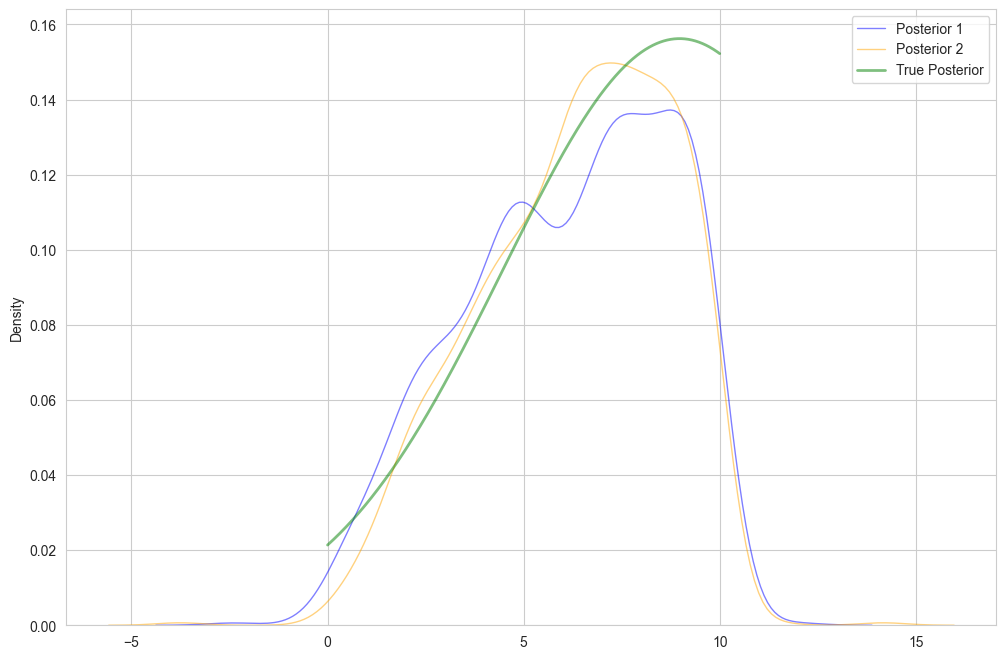

In [18]:
plt.figure(figsize=(12, 8))
sns.set_style('whitegrid')
sns.kdeplot(theta_trained1_numpy[:, 0], label='Posterior 1', color='blue', linewidth=1, alpha=0.5)
sns.kdeplot(theta_trained2_numpy[:, 0], label='Posterior 2', color='orange', linewidth=1, alpha=0.5)
plt.plot(theta_grid, posterior, label='True Posterior', color='green', linewidth=2, alpha=0.5)
plt.legend()
plt.show()

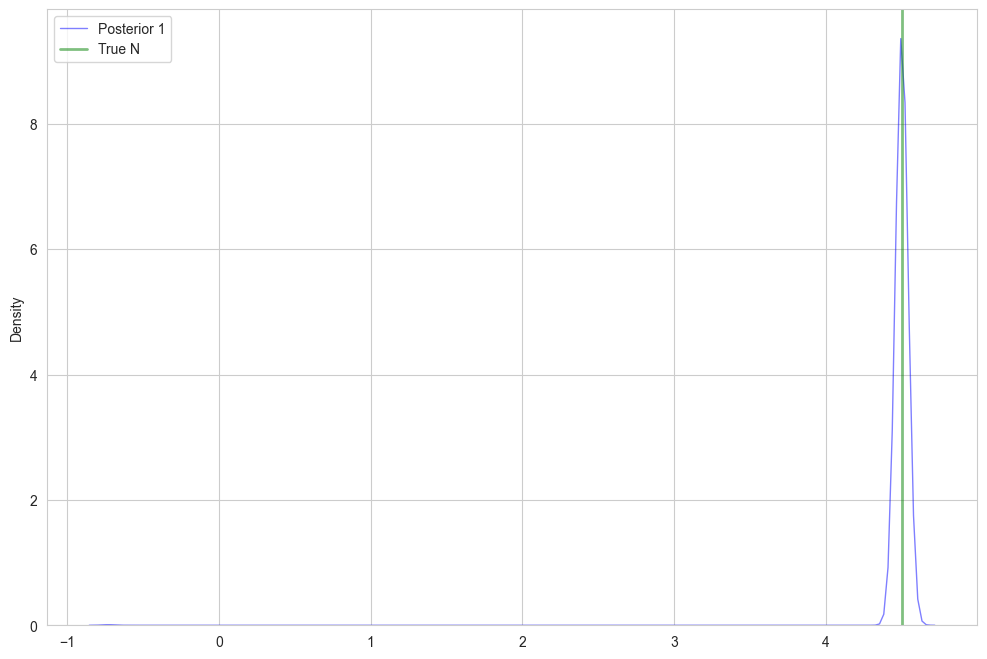

In [20]:
plt.figure(figsize=(12, 8))
sns.set_style('whitegrid')
sns.kdeplot(theta_trained1_numpy[:, 1], label='Posterior 1', color='blue', linewidth=1, alpha=0.5)
plt.axvline(x=true_theta[1], label='True N', color='green', linewidth=2, alpha=0.5)
plt.legend()
plt.show()

### Posterior distribution of $\mu$ that changes by $\sigma$.

In [22]:
sigma_list = [2.0, 4.5, 8.0]

prior_a = 0.0
prior_b = 10.0
theta_grid = np.linspace(0, 10, 1000)
x_o_numpy = x_o.cpu().numpy()

prior_d = uniform.pdf(theta_grid, loc=prior_a, scale=(prior_b - prior_a))

true_posterior_list = []
npe_posterior_list = []
for i in range(len(sigma_list)):
    x_o_numpy[1] = sigma_list[i]
    x_o[1] = sigma_list[i]

    likelihood = norm.pdf(x_o_numpy[0], loc=theta_grid, scale=x_o_numpy[1])
    unnormalized_posterior = likelihood * prior_d
    d_theta = theta_grid[1] - theta_grid[0]
    posterior = unnormalized_posterior / (np.sum(unnormalized_posterior) * d_theta)
    true_posterior_list.append(posterior)

    theta_trained1 = posterior_1.sample((num_posterior_samples,), x=x_o)
    theta_trained1_numpy = theta_trained1.cpu().numpy()
    npe_posterior_list.append(theta_trained1_numpy)

100%|██████████| 1000/1000 [00:00<00:00, 22530.28it/s]


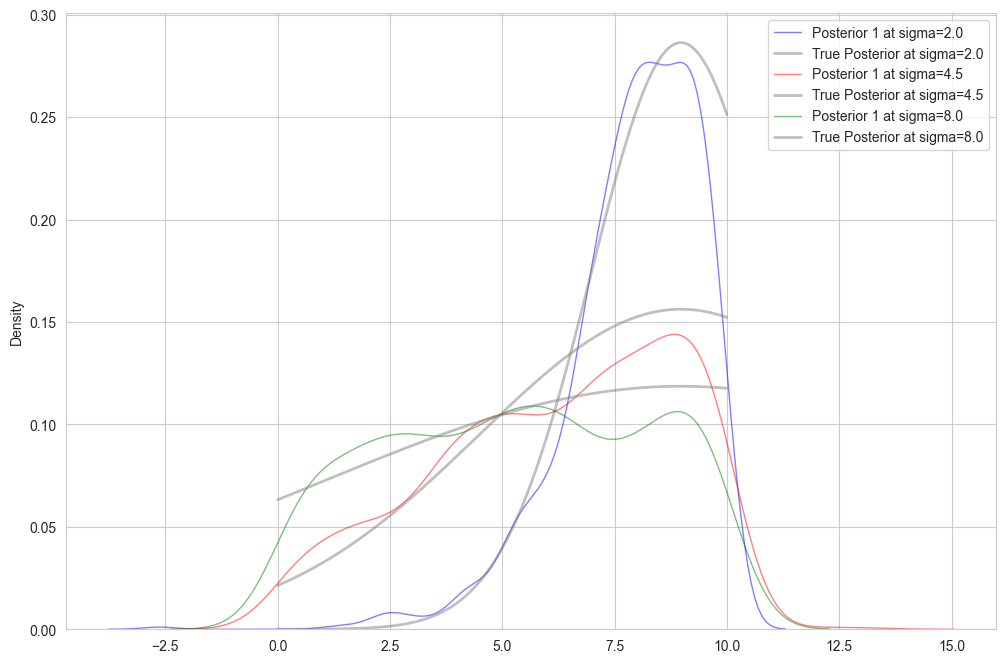

In [25]:
plt.figure(figsize=(12, 8))
sns.set_style('whitegrid')
sns.kdeplot(npe_posterior_list[0][:, 0], label='Posterior 1 at sigma=2.0', color='blue', linewidth=1, alpha=0.5)
plt.plot(theta_grid, true_posterior_list[0], label='True Posterior at sigma=2.0', color='gray', linewidth=2, alpha=0.5)
sns.kdeplot(npe_posterior_list[1][:, 0], label='Posterior 1 at sigma=4.5', color='red', linewidth=1, alpha=0.5)
plt.plot(theta_grid, true_posterior_list[1], label='True Posterior at sigma=4.5', color='gray', linewidth=2, alpha=0.5)
sns.kdeplot(npe_posterior_list[2][:, 0], label='Posterior 1 at sigma=8.0', color='green', linewidth=1, alpha=0.5)
plt.plot(theta_grid, true_posterior_list[2], label='True Posterior at sigma=8.0', color='gray', linewidth=2, alpha=0.5)
plt.legend()
plt.show()

In [26]:
sigma_list = [2.0, 4.5, 8.0]

prior_a = 0.0
prior_b = 10.0
theta_grid = np.linspace(0, 10, 1000)

prior_d = uniform.pdf(theta_grid, loc=prior_a, scale=(prior_b - prior_a))

true_posterior_list = []
npe_posterior_list = []
for i in range(len(sigma_list)):
    x_o_numpy[1] = sigma_list[i]
    x_o[1] = sigma_list[i]

    likelihood = norm.pdf(x_o_numpy[0], loc=theta_grid, scale=x_o_numpy[1])
    unnormalized_posterior = likelihood * prior_d
    d_theta = theta_grid[1] - theta_grid[0]
    posterior = unnormalized_posterior / (np.sum(unnormalized_posterior) * d_theta)
    true_posterior_list.append(posterior)

    theta_trained2 = posterior_2.sample((num_posterior_samples,), x=x_o)
    theta_trained2_numpy = theta_trained2.cpu().numpy()
    npe_posterior_list.append(theta_trained2_numpy)

100%|██████████| 1000/1000 [00:00<00:00, 16655.63it/s]


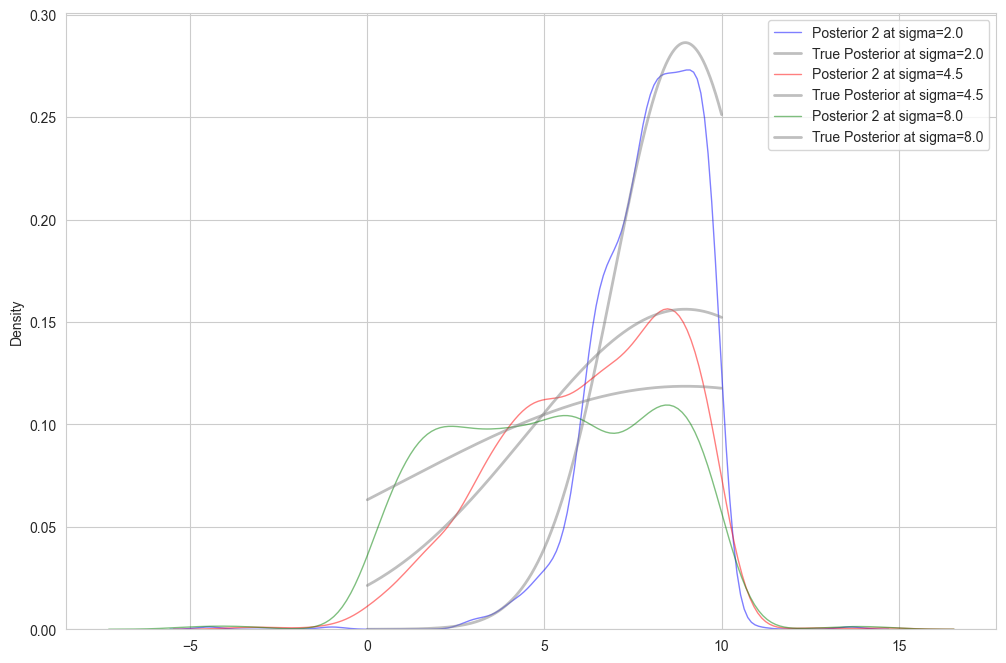

In [28]:
plt.figure(figsize=(12, 8))
sns.set_style('whitegrid')
sns.kdeplot(npe_posterior_list[0][:, 0], label='Posterior 2 at sigma=2.0', color='blue', linewidth=1, alpha=0.5)
plt.plot(theta_grid, true_posterior_list[0], label='True Posterior at sigma=2.0', color='gray', linewidth=2, alpha=0.5)
sns.kdeplot(npe_posterior_list[1][:, 0], label='Posterior 2 at sigma=4.5', color='red', linewidth=1, alpha=0.5)
plt.plot(theta_grid, true_posterior_list[1], label='True Posterior at sigma=4.5', color='gray', linewidth=2, alpha=0.5)
sns.kdeplot(npe_posterior_list[2][:, 0], label='Posterior 2 at sigma=8.0', color='green', linewidth=1, alpha=0.5)
plt.plot(theta_grid, true_posterior_list[2], label='True Posterior at sigma=8.0', color='gray', linewidth=2, alpha=0.5)
plt.legend()
plt.show()

## Model 2

**Prior:**
-  $\mu \sim \text{Uniform}[0, 10]$
-  $\sigma \sim \text{Uniform}[1, 10]$

**Simulator:**
-  $x \sim N(\mu + 0.1 \times \sigma \times \mu^2, \sigma^2)$

In [35]:
theta = np.full((100, 2), np.nan)
theta[:, 0] = np.random.uniform(0, 10, size=100)
theta[:, 1] = np.random.uniform(1, 10, size=100)
mu_y = np.full(100, np.nan)
sigma_y = np.full(100, np.nan)

for i in range(100):
    mu_y[i] = np.random.normal(loc=theta[i, 0]+0.1*3*theta[i, 0]**2, scale=3)
    sigma_y[i] = np.random.normal(loc=5+0.1*theta[i, 1]*5**2, scale=theta[i, 1])

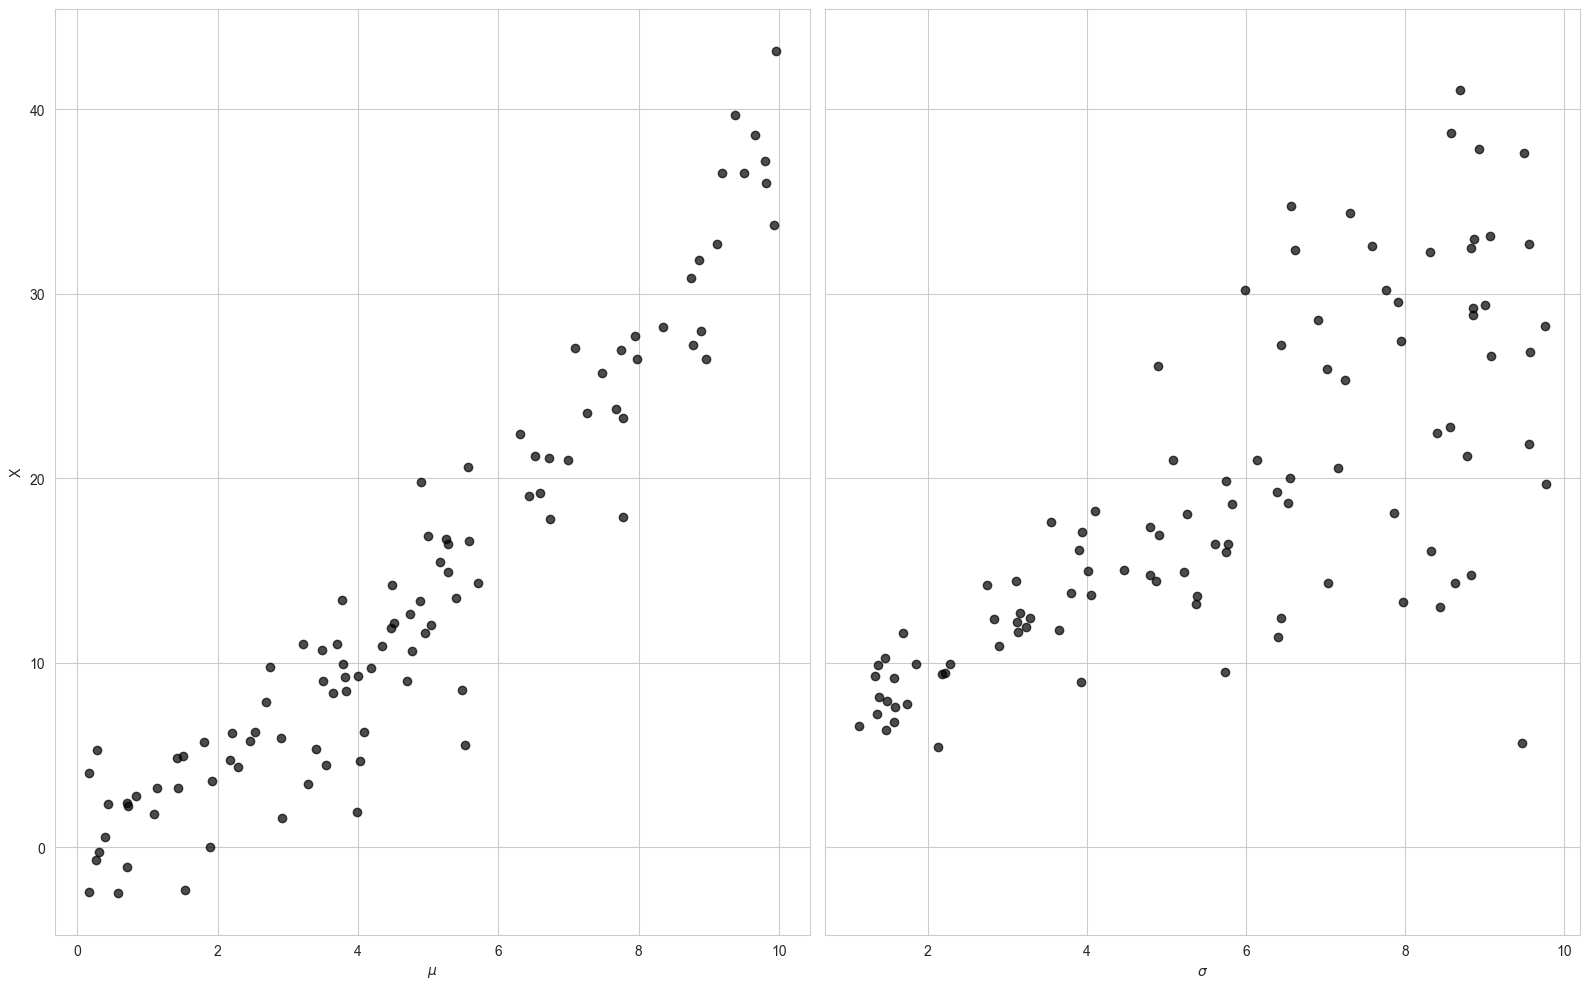

In [36]:
fig, axs = plt.subplots(1, 2, figsize=(16, 10), sharey='row')

axs[0].scatter(theta[:, 0], mu_y, marker='o', color='black', alpha=0.7)
axs[1].scatter(theta[:, 1], sigma_y, marker='o', color='black', alpha=0.7)

axs[0].set_xlabel(r'$\mu$')
axs[1].set_xlabel(r'$\sigma$')

axs[0].set_ylabel('X')

plt.tight_layout()
plt.show()

In [37]:
prior_mu = Uniform(low=torch.tensor([0.0]), high=torch.tensor([10.0]))
prior_sigma = Uniform(low=torch.tensor([1.0]), high=torch.tensor([10.0]))

prior_torch = MultipleIndependent(
    dists=[prior_mu, prior_sigma],
    validate_args=False,
    device=torch_device
)

In [39]:
def simulator_2(theta):
    x = torch.randn(1, device=torch_device) * theta[1] + theta[0] + 0.1 * theta[1] * theta[0]**2
    out_torch = torch.tensor([x, theta[1]], device=torch_device)
    return out_torch

## NPE-C

In [40]:
simulation_budget = 10000
num_posterior_samples=1000
seed = 1

In [41]:
simulator = simulator_2

prior, num_parameters, prior_returns_numpy = process_prior(prior_torch)
simulator = process_simulator(simulator, prior, prior_returns_numpy)
check_sbi_inputs(simulator, prior)

learning_rate = 0.0005  # default value

torch.manual_seed(seed)
np.random.seed(seed)

theta, x = simulate_for_sbi(
    simulator=simulator, proposal=prior, num_simulations=simulation_budget
)

100%|██████████| 10000/10000 [00:01<00:00, 8585.05it/s]


**Simulator 3**

sigma inside the parameter space.

 Training neural network. Epochs trained: 39

For an interactive, detailed view of the summary, launch tensorboard  with 'tensorboard --logdir=c:\Users\u2008181\likelihood-free\python\normal_toy\sbi-logs\NPE_C\2026-06-01T15_32_38.750789' from a terminal on your machine, visit http://127.0.0.1:6006 afterwards. Requires port forwarding if tensorboard runs on a remote machine, as e.g. https://stackoverflow.com/a/42445070/7770835 explains.

Valid tags are: ['best_validation_loss', 'epoch_durations_sec', 'epochs_trained', 'training_loss', 'validation_loss'].


 Neural network successfully converged after 40 epochs.

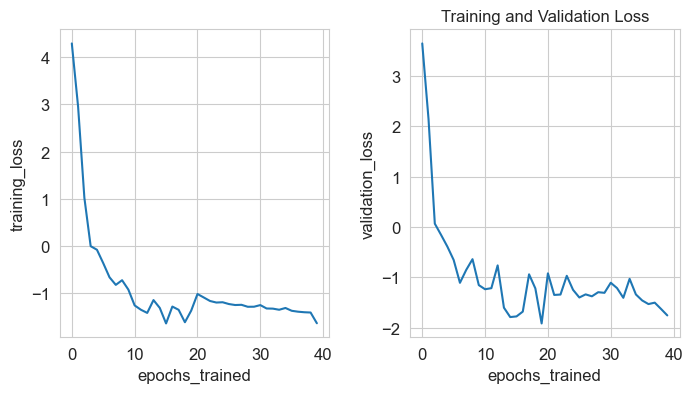

In [42]:
posterior_3 = run_npe(theta, x)

**Simulator 4**

sigma outside the parameter space

In [44]:
theta2 = theta[:, 0:1]
theta2

tensor([[0.2569],
        [0.6235],
        [2.2045],
        ...,
        [9.0977],
        [8.0192],
        [1.6477]])

 Training neural network. Epochs trained: 83

For an interactive, detailed view of the summary, launch tensorboard  with 'tensorboard --logdir=c:\Users\u2008181\likelihood-free\python\normal_toy\sbi-logs\NPE_C\2026-06-01T15_35_53.474133' from a terminal on your machine, visit http://127.0.0.1:6006 afterwards. Requires port forwarding if tensorboard runs on a remote machine, as e.g. https://stackoverflow.com/a/42445070/7770835 explains.

Valid tags are: ['best_validation_loss', 'epoch_durations_sec', 'epochs_trained', 'training_loss', 'validation_loss'].


 Neural network successfully converged after 84 epochs.

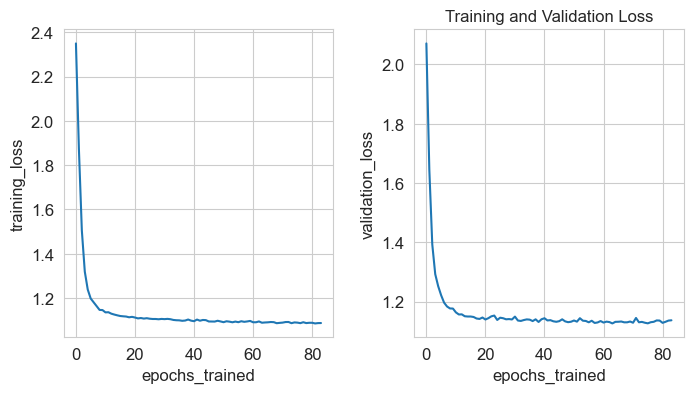

In [45]:
posterior_4 = run_npe(theta2, x)

If the true values are:
-  $\mu = 6.0$,
-  $\sigma = 4.5$.

The observed summary statistics are shown below as

In [46]:
torch.manual_seed(1)
np.random.seed(1)
true_theta = torch.tensor([6.0, 4.5], device=torch_device)
x_o = simulator_2(true_theta)
true_theta, x_o

(tensor([6.0000, 4.5000]), tensor([25.1761,  4.5000]))

Plug in observed data to get the posterior.

In [47]:
theta_trained3 = posterior_3.sample((num_posterior_samples,), x=x_o)
theta_trained3_numpy = theta_trained3.cpu().numpy()

theta_trained4 = posterior_4.sample((num_posterior_samples,), x=x_o)
theta_trained4_numpy = theta_trained4.cpu().numpy()

100%|██████████| 1000/1000 [00:00<00:00, 76923.01it/s]


**True posterior by the truncated normal distribution**

In [ ]:
import math

a = 0.45
b = 1.0
c = -25.1761

discriminant = b**2 - 4 * a * c

x1 = (-b + math.sqrt(discriminant)) / (2 * a)
x2 = (-b - math.sqrt(discriminant)) / (2 * a)

print(f"Solution 1: x = {x1:.4f}")
print(f"Solution 2: x = {x2:.4f}")

Solution 1: x = 6.4507
Solution 2: x = -8.6730


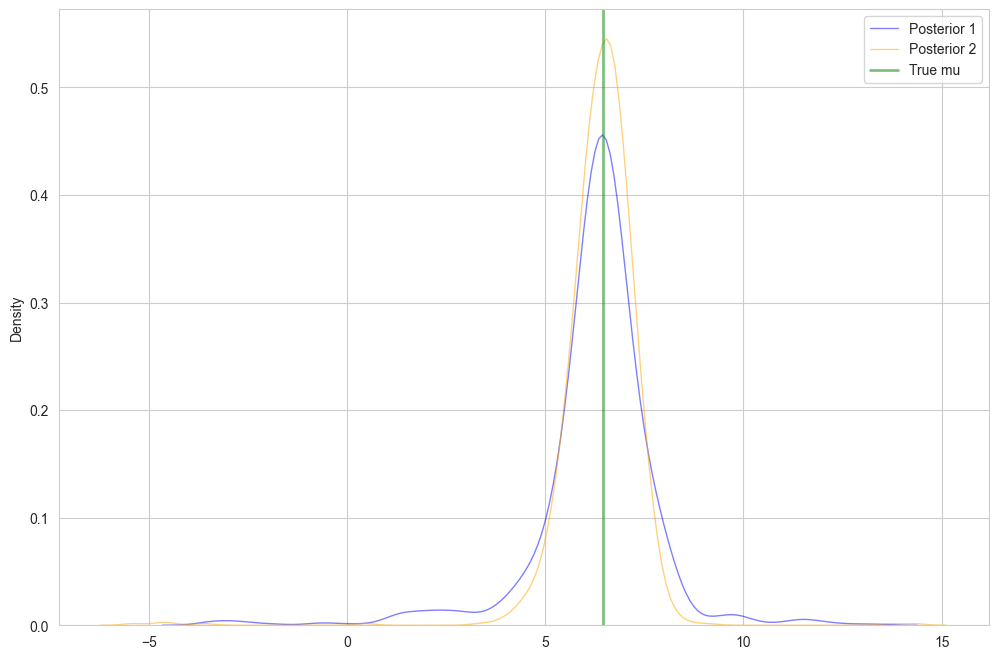

In [56]:
plt.figure(figsize=(12, 8))
sns.set_style('whitegrid')
sns.kdeplot(theta_trained3_numpy[:, 0], label='Posterior 1', color='blue', linewidth=1, alpha=0.5)
sns.kdeplot(theta_trained4_numpy[:, 0], label='Posterior 2', color='orange', linewidth=1, alpha=0.5)
plt.axvline(x=x1, label='True mu', color='green', linewidth=2, alpha=0.5)
plt.legend()
plt.show()

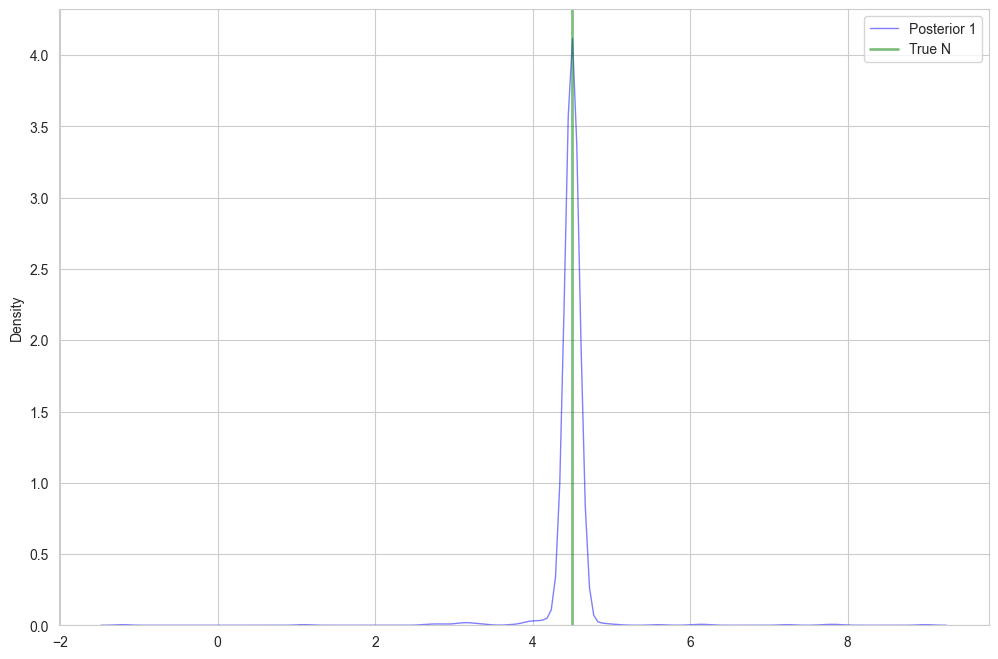

In [57]:
plt.figure(figsize=(12, 8))
sns.set_style('whitegrid')
sns.kdeplot(theta_trained3_numpy[:, 1], label='Posterior 1', color='blue', linewidth=1, alpha=0.5)
plt.axvline(x=true_theta[1], label='True N', color='green', linewidth=2, alpha=0.5)
plt.legend()
plt.show()

### Posterior distribution of $\mu$ that changes by $\sigma$.

In [65]:
import math

a_list = [0.2, 0.45, 0.8]
b = 1.0
c = -25.1761

x1_list = []
x2_list = []
for i in range(len(a_list)):
    a = a_list[i]
    discriminant = b**2 - 4 * a * c

    x1 = (-b + math.sqrt(discriminant)) / (2 * a)
    x2 = (-b - math.sqrt(discriminant)) / (2 * a)

    x1_list.append(x1)
    x2_list.append(x2)

x1_list, x2_list

([8.994803173608497, 6.450731044747702, 5.019532753027482],
 [-13.994803173608497, -8.672953266969923, -6.269532753027482])

In [66]:
sigma_list = [2.0, 4.5, 8.0]

prior_a = 0.0
prior_b = 10.0
theta_grid = np.linspace(0, 10, 1000)
x_o_numpy = x_o.cpu().numpy()

npe_posterior_list = []
for i in range(len(sigma_list)):
    x_o_numpy[1] = sigma_list[i]
    x_o[1] = sigma_list[i]

    theta_trained3 = posterior_3.sample((num_posterior_samples,), x=x_o)
    theta_trained3_numpy = theta_trained3.cpu().numpy()
    npe_posterior_list.append(theta_trained3_numpy)

100%|██████████| 1000/1000 [00:00<00:00, 59881.84it/s]


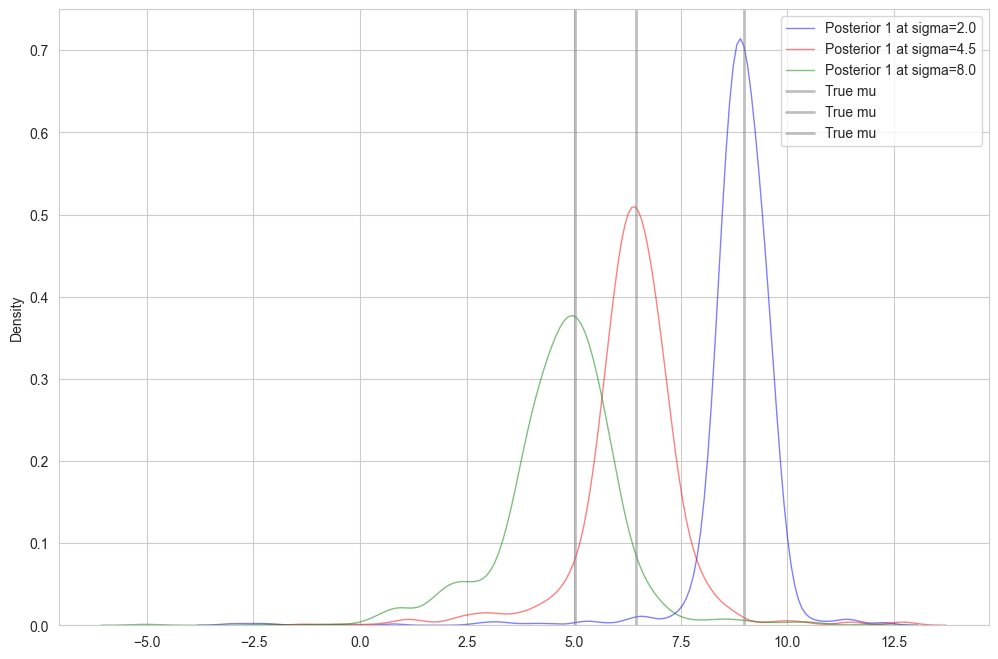

In [67]:
plt.figure(figsize=(12, 8))
sns.set_style('whitegrid')
sns.kdeplot(npe_posterior_list[0][:, 0], label='Posterior 1 at sigma=2.0', color='blue', linewidth=1, alpha=0.5)
sns.kdeplot(npe_posterior_list[1][:, 0], label='Posterior 1 at sigma=4.5', color='red', linewidth=1, alpha=0.5)
sns.kdeplot(npe_posterior_list[2][:, 0], label='Posterior 1 at sigma=8.0', color='green', linewidth=1, alpha=0.5)
plt.axvline(x=x1_list[0], label='True mu', color='gray', linewidth=2, alpha=0.5)
plt.axvline(x=x1_list[1], label='True mu', color='gray', linewidth=2, alpha=0.5)
plt.axvline(x=x1_list[2], label='True mu', color='gray', linewidth=2, alpha=0.5)
plt.legend()
plt.show()

In [68]:
sigma_list = [2.0, 4.5, 8.0]

prior_a = 0.0
prior_b = 10.0
theta_grid = np.linspace(0, 10, 1000)

prior_d = uniform.pdf(theta_grid, loc=prior_a, scale=(prior_b - prior_a))

npe_posterior_list = []
for i in range(len(sigma_list)):
    x_o_numpy[1] = sigma_list[i]
    x_o[1] = sigma_list[i]

    theta_trained4 = posterior_4.sample((num_posterior_samples,), x=x_o)
    theta_trained4_numpy = theta_trained4.cpu().numpy()
    npe_posterior_list.append(theta_trained4_numpy)

100%|██████████| 1000/1000 [00:00<00:00, 105178.39it/s]


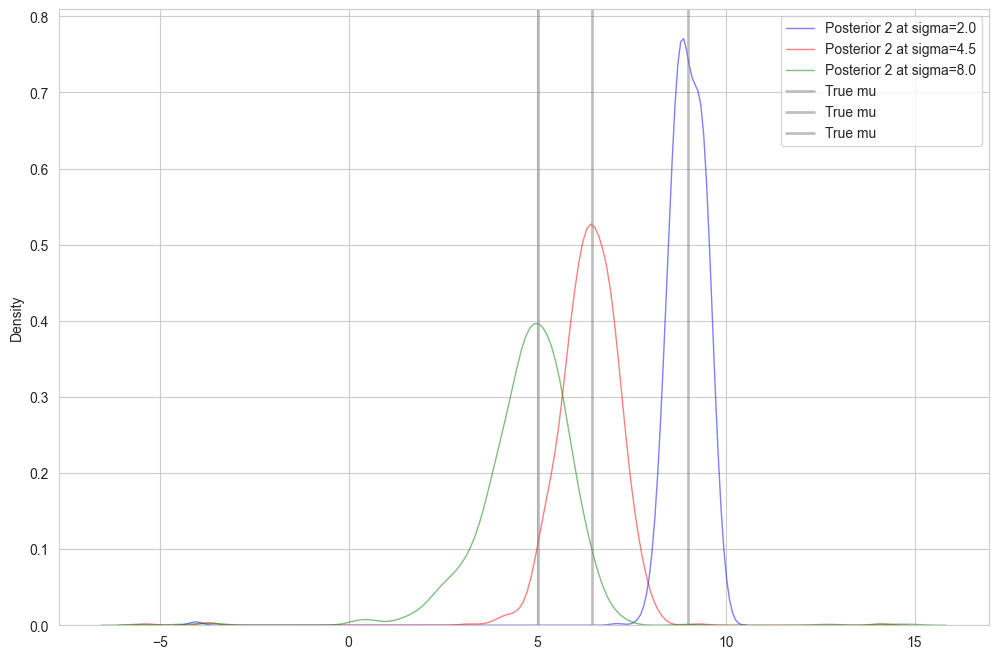

In [69]:
plt.figure(figsize=(12, 8))
sns.set_style('whitegrid')
sns.kdeplot(npe_posterior_list[0][:, 0], label='Posterior 2 at sigma=2.0', color='blue', linewidth=1, alpha=0.5)
sns.kdeplot(npe_posterior_list[1][:, 0], label='Posterior 2 at sigma=4.5', color='red', linewidth=1, alpha=0.5)
sns.kdeplot(npe_posterior_list[2][:, 0], label='Posterior 2 at sigma=8.0', color='green', linewidth=1, alpha=0.5)
plt.axvline(x=x1_list[0], label='True mu', color='gray', linewidth=2, alpha=0.5)
plt.axvline(x=x1_list[1], label='True mu', color='gray', linewidth=2, alpha=0.5)
plt.axvline(x=x1_list[2], label='True mu', color='gray', linewidth=2, alpha=0.5)
plt.legend()
plt.show()